## Introduction

The eConsult program was established as a collaboration between FLIPA and several FLIPA Member Health Centers. Through this program, Primary Care Providers (PCPs) and patients were connected via telehealth consultation to medical specialist providers to help alleviate patient wait times and other barriers to access for patients seeking consultation with specialist providers. This preliminary analysis was completed in an effort to understand the impact of eConsults on participating patient health outcomes.

### Data Collection

Data were prepared using Power Query and analyzed using Power BI. eConsults data from Dec. 2024 through Jun. 2025 were appended to create a comprehensive table of all eConsults. This table was merged against the latest Fidelis All Member report (PT March 2025) and United Healthcare All Member report (July 2025) to match recipients of eConsults with their Medicaid CIN.
Patient claims data were pulled from the FLIPA data warehouse Fact_Claims table, filtered to include only claims for individuals who participated in eConsults, for whom a CIN was able to be identified (n=168). Claims data were pulled from the time period of 6/1/2024 through 7/17/2025. No claims were found for individuals that participated in eConsults with obtained CINs in June or July (through the 17th).
Claim types were grouped into the following categories:
Preventive: Primary care, Professional, Pharmacy
Unmanaged: Emergency room, inpatient

Imports

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering

import warnings
warnings.filterwarnings('ignore')

### Loading the Data

The data will first be loaded to view the features we will be working with and begin the cleaning process.

In [2]:
df=pd.read_csv("eConsults Data (eConsults).csv")
df.head()

,eConsult ID,Patient First Name,Patient Last Name,Account No. (MRN),Insurance No.,DOB,Payer-C,Insurer-C,Created By,SR Org,...,PCP NPI,CPT Code,Diag Code,ICD Description,Ped/Adult,UUI,Created Date (bins),Other Specialty Group,Specialty Combined,Specialty Combined + Other
0,14203743,MAHIYA,AKTER,165464,NaN,"Mon, 02 Dec 2024 00:00:00",Finger Lakes IPA,Uninsured,Lauren Field,CECN,...,1205169372,99451,P55.9,"HEMOLYTIC DISEASE OF NEWBORN, UNSPECIFIED",Ped,"AKTER, MAHIYA-12/2/2024","Sun, 01 Dec 2024 00:00:00",Pediatric Hematology,Hematology,Hematology
1,14204090,NAWZINNIA,OO,154166,746156217,"Wed, 30 Mar 1949 00:00:00",Finger Lakes IPA,M Fidelis Care,Lauren Field,CECN,...,1205169372,99451,D56.3,THALASSEMIA MINOR,Adult,"OO, NAWZINNIA-3/30/1949","Sun, 01 Dec 2024 00:00:00",Hematology,Hematology,Hematology
2,14205736,DIONICIA,POLANCO,74915,74141921900,"Wed, 15 Jun 1977 00:00:00",Finger Lakes IPA,M Fidelis Care,Lauren Field,CECN,...,1518912641,99451,E06.3,AUTOIMMUNE THYROIDITIS,Adult,"POLANCO, DIONICIA-6/15/1977","Sun, 01 Dec 2024 00:00:00",Endocrinology,Endocrinology,Endocrinology
3,14207742,LYNN,SKELLY,74093,74317957900,"Sat, 16 Nov 1974 00:00:00",Finger Lakes IPA,M Fidelis Care,Lauren Field,CECN,...,1518912641,99451,F41.9,"ANXIETY DISORDER, UNSPECIFIED",Adult,"SKELLY, LYNN-11/16/1974","Sun, 01 Dec 2024 00:00:00",Psychiatry,Psychiatry,Psychiatry
4,14208361,NURZIYAH,ESANULLAH,156699,74652696000,"Fri, 25 Jan 2013 00:00:00",Finger Lakes IPA,M Fidelis Care,Lauren Field,CECN,...,1326334590,99451,D64.9,"ANEMIA, UNSPECIFIED",Ped,"ESANULLAH, NURZIYAH-1/25/2013","Sun, 01 Dec 2024 00:00:00",Pediatric Hematology,Hematology,Hematology


In [3]:
df_econsults=pd.read_csv("econsults model data.csv")
df_econsults.head()

,Patient First Name,Patient Last Name,Practice_Name,Encounter_ID,Service_Date,Sum of Paid_Amount,Paid_Date,Primary_Diag_Code,Transaction_Desc,Transaction_Classification,Drug_Name,Coverage_Type
0,AALIYAH,ODONNELL,COMMUNITY HEALTH CENTER OF THE NORTH COUNTRY,17368212,2026-01-05 00:00:00,$131.16,2026-01-30 00:00:00,Z00.01,PRIMARY CARE VISIT,PROFESSIONAL,NaN,PART B
1,AALIYAH,ODONNELL,COMMUNITY HEALTH CENTER OF THE NORTH COUNTRY,17421654,2026-02-26 00:00:00,$131.16,2026-03-27 00:00:00,N91.2,PRIMARY CARE VISIT,PROFESSIONAL,NaN,PART B
2,AALIYAH,ODONNELL,COMMUNITY HEALTH CENTER OF THE NORTH COUNTRY,17431780,2026-03-05 00:00:00,$167.42,2026-03-14 00:00:00,NaN,DENTAL,PROFESSIONAL,NaN,PART B
3,AALIYAH,ODONNELL,COMMUNITY HEALTH CENTER OF THE NORTH COUNTRY,17436862,2026-02-02 00:00:00,$106.00,2026-02-27 00:00:00,H66.91,OTHER PART B,PROFESSIONAL,NaN,PART B
4,AALIYAH,ODONNELL,COMMUNITY HEALTH CENTER OF THE NORTH COUNTRY,17447597,2026-02-02 00:00:00,$0.00,2026-02-02 00:00:00,NaN,PART D RX,PHARMACY,AMOXICILLIN,PART D


In [4]:
print(df_econsults.columns.tolist())

['Patient First Name', 'Patient Last Name', 'Practice_Name', 'Encounter_ID', 'Service_Date', 'Sum of Paid_Amount', 'Paid_Date', 'Primary_Diag_Code', 'Transaction_Desc', 'Transaction_Classification', 'Drug_Name', 'Coverage_Type']


In [ ]:
encounter_count = df_econsults['Encounter_ID'].nunique()
print("encounters:", encounter_count)

encounters: 26163


In [4]:
size=df.shape
numerical=df.select_dtypes(include=['number']).shape[1]
categorical=df.select_dtypes(exclude=['number']).shape[1]

print(size)
print(numerical)
print(categorical)

(2125, 33)
8
25


### Cleaning the Data

checked for missing values, confirmed data types are correct:

In [5]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2125 entries, 0 to 2124
Data columns (total 33 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   eConsult ID                 2125 non-null   int64  
 1   Patient First Name          2125 non-null   object 
 2   Patient Last Name           2125 non-null   object 
 3   Account No. (MRN)           2123 non-null   object 
 4   Insurance No.               1956 non-null   object 
 5   DOB                         2125 non-null   object 
 6   Payer-C                     2125 non-null   object 
 7   Insurer-C                   2121 non-null   object 
 8   Created By                  2106 non-null   object 
 9   SR Org                      2125 non-null   object 
 10  Specialist Name             2125 non-null   object 
 11  SR NPI                      2125 non-null   int64  
 12  Specialty                   2125 non-null   object 
 13  Created Date                2125 

eConsult ID                     0
Patient First Name              0
Patient Last Name               0
Account No. (MRN)               2
Insurance No.                 169
DOB                             0
Payer-C                         0
Insurer-C                       4
Created By                     19
SR Org                          0
Specialist Name                 0
SR NPI                          0
Specialty                       0
Created Date                    0
Consult Submitted               0
First Response                  0
Closed Date                     0
Specialist Recommendation       0
# PCP-SR Exchanges             19
NetName                         0
PCP Site                        0
PCP Name                       19
PCP Title                     137
PCP NPI                         0
CPT Code                        0
Diag Code                       0
ICD Description                 0
Ped/Adult                       0
UUI                             0
Created Date (

In [12]:
null=df.isnull().sum()
print(null[null>0])

Series([], dtype: int64)


In [43]:
print(df_econsults_filtered.head(100))

    eConsult ID Patient First Name Patient Last Name Account No. (MRN)  \
0      14203743             MAHIYA             AKTER            165464   
1      14204090          NAWZINNIA                OO            154166   
2      14205736           DIONICIA           POLANCO             74915   
3      14207742               LYNN            SKELLY             74093   
4      14208361           NURZIYAH         ESANULLAH            156699   
..          ...                ...               ...               ...   
95     14388318        CHRISTOPHER             SYKES            161684   
96     14388801            HEATHER           WICKHAM             31280   
97     14389576             SHELLY         GRABOWSKI            156333   
98     14393417            MICHAEL         DIGEORGIO            151444   
99     14394620               LUNA               LIN            139986   

   Insurance No.                        DOB           Payer-C  \
0            NaN  Mon, 02 Dec 2024 00:00:00  F

Now that null values have been identified, categorical versus numerical columns will be separated, and then missing values will be filled with either mean data if it is numerical (as recommended by the dataset source) or mode data if it is categorical data.

In [7]:
numerical=df.select_dtypes(include=[np.number]).columns
categorical=df.select_dtypes(exclude=[np.number]).columns
for col in numerical:
    df[col]=df[col].fillna(df[col].mean())
for col in categorical:
    df[col]=df[col].fillna(df[col].mode()[0])

In [8]:
df.isnull().sum()

eConsult ID                   0
Patient First Name            0
Patient Last Name             0
Account No. (MRN)             0
Insurance No.                 0
DOB                           0
Payer-C                       0
Insurer-C                     0
Created By                    0
SR Org                        0
Specialist Name               0
SR NPI                        0
Specialty                     0
Created Date                  0
Consult Submitted             0
First Response                0
Closed Date                   0
Specialist Recommendation     0
# PCP-SR Exchanges            0
NetName                       0
PCP Site                      0
PCP Name                      0
PCP Title                     0
PCP NPI                       0
CPT Code                      0
Diag Code                     0
ICD Description               0
Ped/Adult                     0
UUI                           0
Created Date (bins)           0
Other Specialty Group         0
Specialt

Since our task involves clustering, we will encode categorical columns to numeric values, since clustering cannot work with text. 

In [9]:
encode=pd.get_dummies(df,drop_first=True)

In [10]:
print(encode.head())

   eConsult ID      SR NPI  Consult Submitted  First Response  Closed Date  \
0     14203743  1265776587        45637.57292     45637.58819  45637.58819   
1     14204090  1437146552        45637.70556     45641.55139  45641.55139   
2     14205736  1659417889        45639.54306     45639.55347  45639.55347   
3     14207742  1154397289        45642.83056     45642.98750  45642.98750   
4     14208361  1265776587        45643.64722     45643.66111  45643.66111   

   # PCP-SR Exchanges     PCP NPI  CPT Code  Patient First Name_AARON  \
0                 2.0  1205169372     99451                     False   
1                 2.0  1205169372     99451                     False   
2                 2.0  1518912641     99451                     False   
3                 2.0  1518912641     99451                     False   
4                 2.0  1326334590     99451                     False   

   Patient First Name_ABBY  ...  Specialty Combined + Other_Nephrology  \
0                 

The next and final step to account for clustering is to scale the data so that all variables are all on the same scale.

In [52]:
scaler=StandardScaler()
xscaled=scaler.fit_transform(encode)

### Exploratory Data Analysis (EDA)

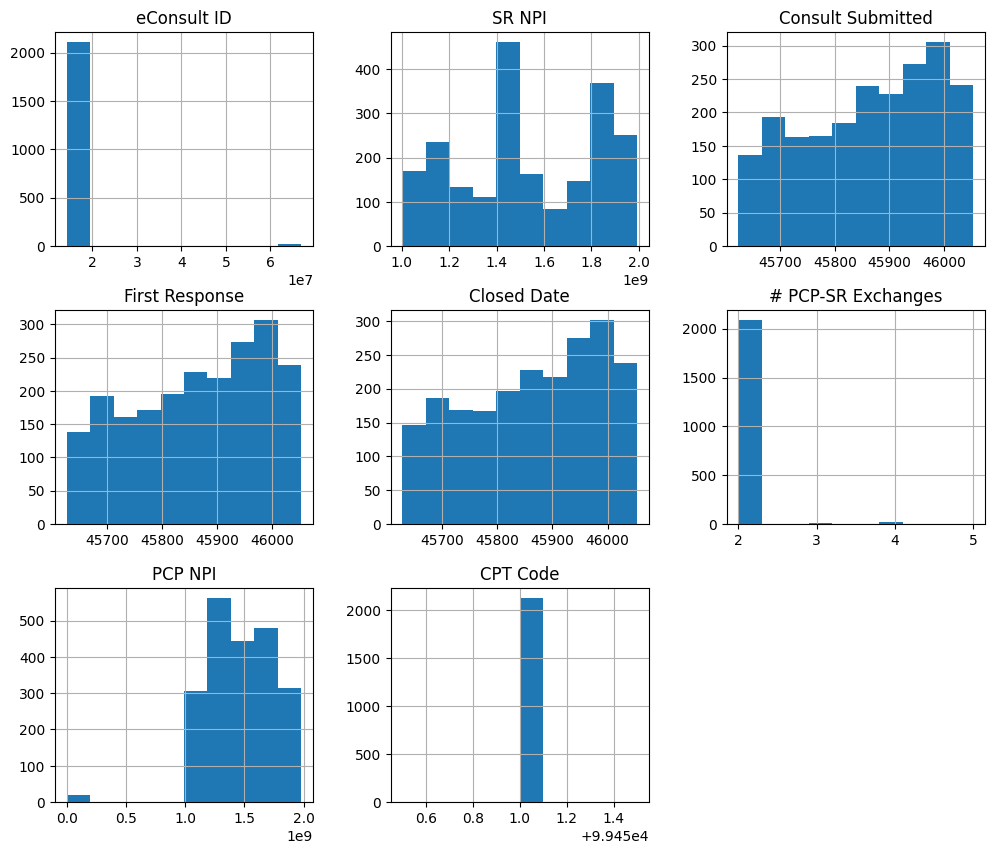

In [53]:
encode.hist(figsize=(12,10))
plt.show()

**Correlation Matrix**

**Identifying Outliers**

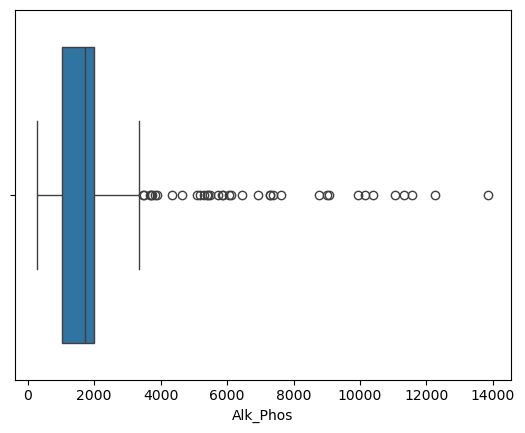

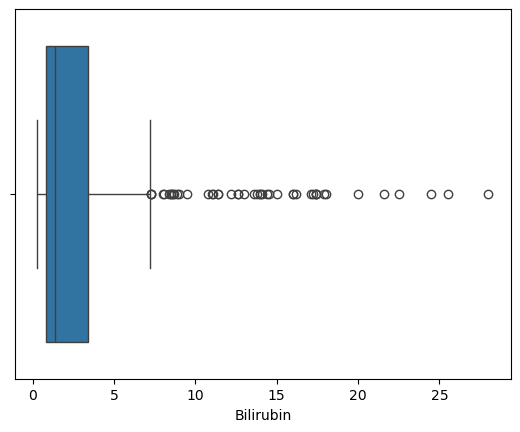

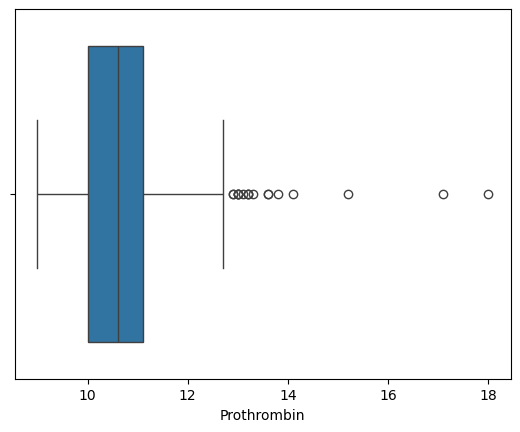

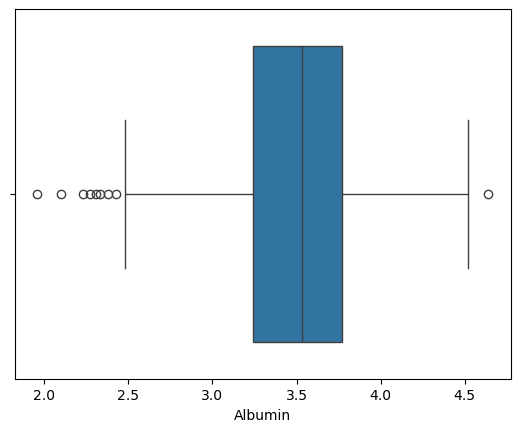

In [ ]:
sns.boxplot(x=encode['Alk_Phos'])
plt.show()
sns.boxplot(x=encode['Bilirubin'])
plt.show()
sns.boxplot(x=encode['Prothrombin'])
plt.show()
sns.boxplot(x=encode['Albumin'])
plt.show()

In these boxplots, both alkaline phophatase and bilirubin showed a strong right distribution with multiple outliers, which could be attributed to patients with a more severe form of liver dysfunction.

## Performing Analysis with Unsupervised Models

After cleaning the data and exploratory analysis, unsupervised models will be used to identify groupings between patients. For this project, we will use multiple models to examine and compare which model had best examined underlying patterns in the data. KMeans will be used as a baseline model since it is able to perform well in identifying clusters within numerical data that are easy to interpret. Agglomerative clustering will also be used as a model to compare to KMeans in terms of performance because it can observe hierarchal relationships well.

**KMeans**

To determine the number of clusters we need for KMeans, we can use the elbow method and select the best K where we start to see diminishing rates in inertia (sum of square distance).

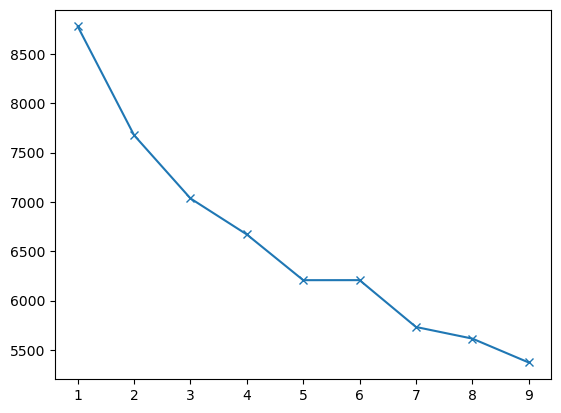

In [ ]:
inertia=[]
for k in range(1,10):
    kmeans=KMeans(n_clusters=k, random_state=42)
    kmeans.fit(xscaled)
    inertia.append(kmeans.inertia_)
plt.plot(range(1,10),inertia,marker='x')
plt.show()

Based on the plot, it appears k=5 is around when the curve begins to flatten from the beginning sharp increase.

Fitting the KMeans:

In [ ]:
kmeans=KMeans(n_clusters=5, random_state=42)
labels=kmeans.fit_predict(xscaled)

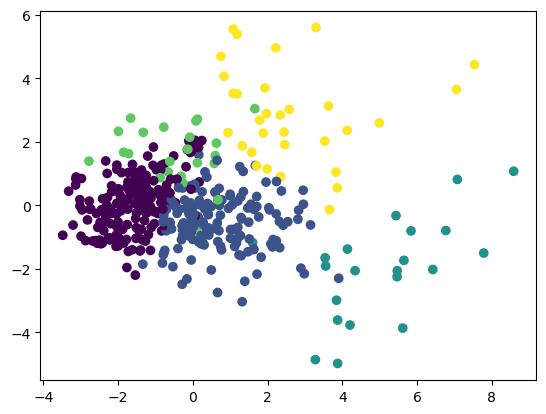

In [ ]:
pca=PCA(n_components=2)
X_pca=pca.fit_transform(xscaled)
plt.scatter(X_pca[:,0],X_pca[:,1], c=labels)
plt.show()

The technique of clustering can also be observed by calculating for the silhouette score of this model.

In [ ]:
kmscore=silhouette_score(xscaled, labels)
print(kmscore)

0.12636146303387596


Finally, the cluster size will be examine to view if clusters are balanced.

In [ ]:
kmclustersize=pd.Series(labels).value_counts()
print(kmclustersize)

0    182
1    160
4     31
3     24
2     21
Name: count, dtype: int64


**Agglomerative Clustering**

After determining the appropriate k for KMeans, we will repeat the evaluation process with agglomerative clustering to compare differences in performance and clustering.

In [ ]:
agglomerative=AgglomerativeClustering(n_clusters=5)
agglabels=agglomerative.fit_predict(xscaled)

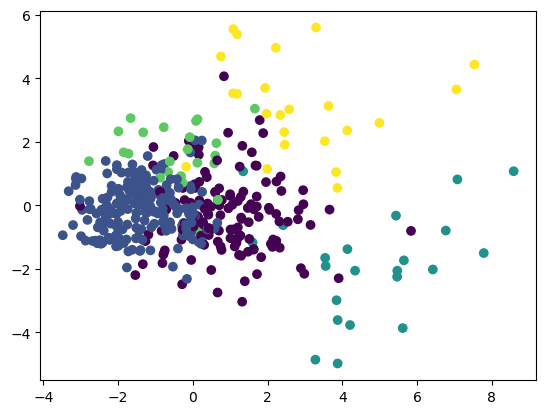

In [ ]:
plt.figure()
plt.scatter(X_pca[:,0],X_pca[:,1],c=agglabels)
plt.show()

The silhouette score was also calculated for agglomerative clustering so that both models could be compared.

In [ ]:
aggscore=silhouette_score(xscaled,agglabels)
print(aggscore)

0.13911091016435342


In [ ]:
aggclustersize=pd.Series(agglabels).value_counts()
print(aggclustersize)

1    203
0    145
3     24
4     24
2     22
Name: count, dtype: int64


**Comparing the Models**

In [ ]:
compare=pd.DataFrame({
    'model':['KMeans','agglomerative'],
    'silhouette score':[kmscore,aggscore],
    'cluster size':[list(kmclustersize),list(aggclustersize)]
})
compare

,model,silhouette score,cluster size
0,KMeans,0.126361,"[182, 160, 31, 24, 21]"
1,agglomerative,0.139111,"[203, 145, 24, 24, 22]"


**Summary:** Based on our assessment of model performance, both models performed similarly, with agglomerative clustering obtained a slightly higher silhouette score, which means it performed better at separating clusters. The observed cluster sizes are similar, which shows that models have the ability to observe the same groupings within the dataset. The PCA visuals also show that both models were able to plot the same distribution, with an observable dense group surrounded by smaller clusters of more extreme records. 

## Interpreting the clusters

Let's compare clusters from both models to examine any identified relationships between features. The feature values for both the KMeans and the Agglomerative Clustering model will be standardized in order for features to be compared fairly and allow for an easier interpretation.

In [ ]:
km_df=encode.copy()
km_df['cluster']=labels
km=km_df.groupby('cluster').mean()

agg_df=encode.copy()
agg_df['cluster']=agglabels
agg=agg_df.groupby('cluster').mean()

In [ ]:
factors=[
    'Bilirubin',
    'Albumin',
    'Prothrombin',
    'Alk_Phos'
]

In [ ]:
kmscaled=pd.DataFrame(
    StandardScaler().fit_transform(km[factors]),
    columns=factors,
    index=km.index
)
aggscaled=pd.DataFrame(
    StandardScaler().fit_transform(agg[factors]),
    columns=factors,
    index=agg.index
)

**KMeans**

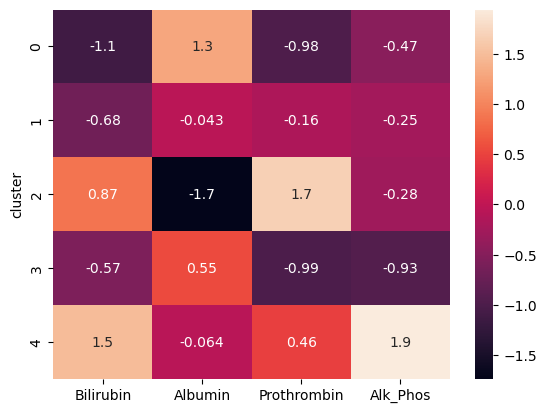

In [ ]:
plt.figure()
sns.heatmap(kmscaled, annot=True)
plt.show()

**Agglomerative Clustering**

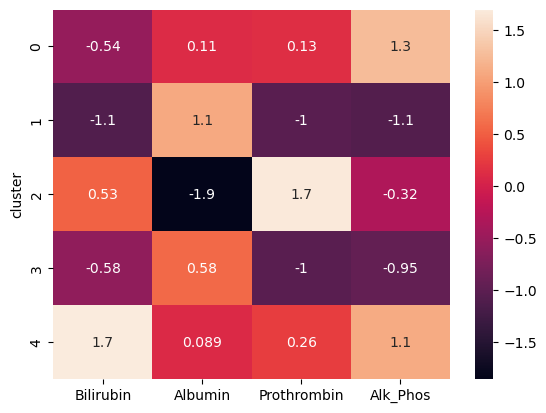

In [ ]:
plt.figure()
sns.heatmap(aggscaled, annot=True)
plt.show()

**Summary**: The clusters were compared for both KMeans and Agglomerative, which yielded very similar patterns. Cluster 1 characterizes a healthier profile of patients among both models, as shown by mostly negative values. The second cluster shows elevated Prothrombin and Bilirubin levels while Albumin is much lower than other clusters. Cluster 3 shows both a decrease in Prothrombin and Alkaline Phosphate, while Albumin is slightly positive. Cluster 4 characterizes the severe cases, where Bilirubin and Alkaline Phosphate are highest, with Prothrombin also being slightly elevated. <br>
Through both of these models, a stable pattern can be shown about underlying patterns in the data by separating the high risk and low risk profiles. Looking at Agglomertive Clustering, it was slightly better at capturing a better distinction between low risk and high risk profiles, which was observed earlier when calculating the silhouette score.

## Discussion and Conclusion

Based on our findings, both KMeans and Agglomerative Clustering were able to reveal similar underlying patterns within the dataset concerning Liver cirrhosis outcome data. EDA demonstrated the presence of right-skewed features such as Bilirubin and Alkaline Phosphatase, which were hypothesized as being important features for this analysis. When comparing between both models, the cluster size and feature means were similar, with Agglomerative Clustering slightly outranking KMeans for the silhouette score. This means that Agglomerative Clustering achieved better separation, but overall analysis still revealed similar results for both models. The interpretation of the clusters showed that patients with more severe disease patterns had elevated Bilirubin and Prothrombin levels, while also demonstrating lower Albumin levels than healthier patients. Some limitations that were found in this project was that the silhouette score was relatively low, which may reveal that the amount of separation between groups is limited. EDA also revealed that many outliers in the data were present, which may have influenced cluster formation and overall bias for model performance. In the future, work can be improved for this project by testing out additional clustering methods such as Gaussian models in order to examine data structures of a higher complexity. 